In [101]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [102]:

#load data
df = pd.read_csv("/Users/haarism/Projects/world-empires-project/data.csv")
df.head()

,empire,empire_start,empire_end,god,king,coin,trade,country_name,country_iso,geo,begin,end,capital
0,Achaemenid Empire,-550,-330,1,1,1,NaN,Afghanistan,AFG,Asia,-530,-331,0.0
1,Achaemenid Empire,-550,-330,1,1,1,NaN,United Arab Emirates,ARE,Asia,-530,-331,0.0
2,Achaemenid Empire,-550,-330,1,1,1,NaN,Armenia,ARM,Asia,-550,-331,0.0
3,Achaemenid Empire,-550,-330,1,1,1,NaN,Azerbaijan,AZE,Asia,-550,-331,0.0
4,Achaemenid Empire,-550,-330,1,1,1,NaN,Bulgaria,BGR,Europe,-512,-479,0.0


In [103]:
#check dataset shape
df.shape

(1536, 13)

In [104]:
#display dataset column names
df.columns

Index(['empire', 'empire_start', 'empire_end', 'god', 'king', 'coin', 'trade',
       'country_name', 'country_iso', 'geo', 'begin', 'end', 'capital'],
      dtype='object')

In [105]:
#data types of each column
df.dtypes

empire           object
empire_start      int64
empire_end        int64
god               int64
king              int64
coin              int64
trade           float64
country_name     object
country_iso      object
geo              object
begin             int64
end               int64
capital         float64
dtype: object

In [106]:
#look for missing values 
missing = df.isnull().sum()
missing

empire             0
empire_start       0
empire_end         0
god                0
king               0
coin               0
trade           1231
country_name       0
country_iso        0
geo                0
begin              0
end                0
capital            4
dtype: int64

Text(0.5, 1.0, 'Missing Values Heatmap')

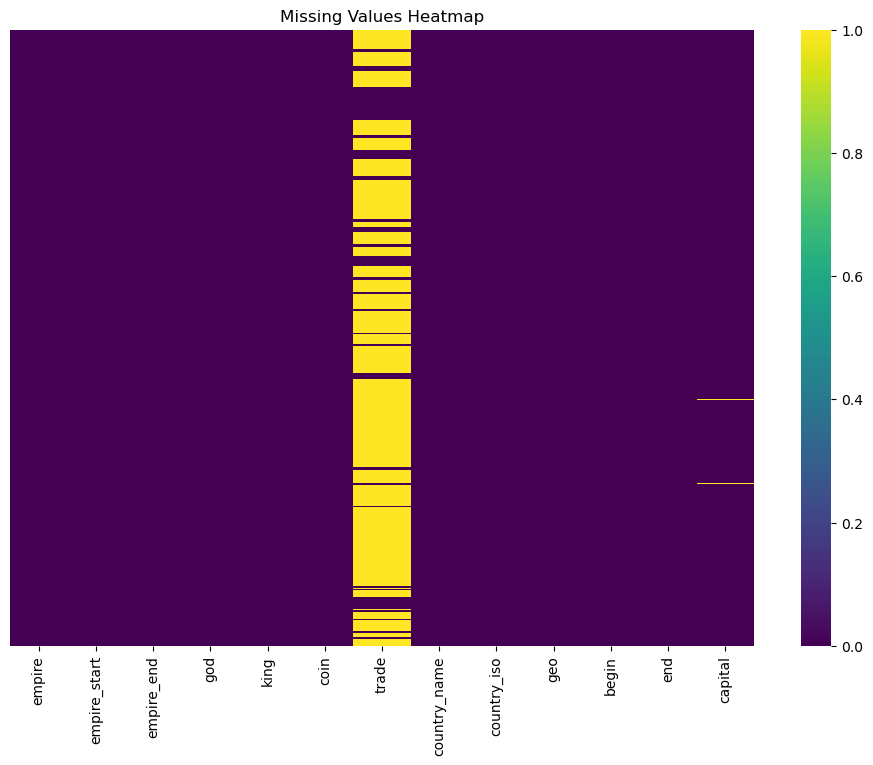

In [107]:
#Heatmap provising overall idea on missing values
plt.figure(figsize=(12, 8))  
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")

Only two features in the dataset contain missing values, trade has the most missing values, showing majority of empires did not conduct internal trade. The other feature is capital which has only four missing values, most likely will be replaced with the mean or mode. 

In [108]:
#data needs aggregated because there are duplicates in the data,
#where empires that have ruled different regions have more rows for each of these regions
df.groupby("empire").describe()


empire_start                                       \
                            count    mean  std     min     25%     50%   
empire                                                                   
Abbasid Empire               30.0   750.0  0.0   750.0   750.0   750.0   
Aceh Sultanate                2.0  1528.0  0.0  1528.0  1528.0  1528.0   
Achaemenid Empire            31.0  -550.0  0.0  -550.0  -550.0  -550.0   
Afsharid Dynasty             18.0  1736.0  0.0  1736.0  1736.0  1736.0   
Ajuran Sultanate              2.0  1250.0  0.0  1250.0  1250.0  1250.0   
...                           ...     ...  ...     ...     ...     ...   
Wei Empire                    2.0   220.0  0.0   220.0   220.0   220.0   
Western Roman Empire         25.0   395.0  0.0   395.0   395.0   395.0   
Western Xia Dynasty           2.0  1038.0  0.0  1038.0  1038.0  1038.0   
Yuan Dynasty                  8.0  1271.0  0.0  1271.0  1271.0  1271.0   
Zand Dynasty                  6.0  1750.0  0.0  1750.0  1750.0  1750.0   

                                     empire_end          ...     end          \
                         75%     max      count    mean  ...     75%     max   
empire                                                   ...                   
Abbasid Empire         750.0   750.0       30.0  1258.0  ...  1258.0  1258.0   
Aceh Sultanate        1528.0  1528.0        2.0  1903.0  ...  1903.0  1903.0   
Achaemenid Empire     -550.0  -550.0       31.0  -330.0  ...  -331.0  -330.0   
Afsharid Dynasty      1736.0  1736.0       18.0  1796.0  ...  1796.0  1796.0   
Ajuran Sultanate      1250.0  1250.0        2.0  1650.0  ...  1650.0  1650.0   
...                      ...     ...        ...     ...  ...     ...     ...   
Wei Empire             220.0   220.0        2.0   265.0  ...   265.0   265.0   
Western Roman Empire   395.0   395.0       25.0   476.0  ...   476.0   476.0   
Western Xia Dynasty   1038.0  1038.0        2.0  1227.0  ...  1227.0  1227.0   
Yuan Dynasty          1271.0  1271.0        8.0  1368.0  ...  1368.0  1368.0   
Zand Dynasty          1750.0  1750.0        6.0  1794.0  ...  1794.0  1794.0   

                     capital                                                 
                       count      mean       std  min   25%  50%   75%  max  
empire                                                                       
Abbasid Empire          30.0  0.033333  0.182574  0.0  0.00  0.0  0.00  1.0  
Aceh Sultanate           2.0  0.500000  0.707107  0.0  0.25  0.5  0.75  1.0  
Achaemenid Empire       31.0  0.032258  0.179605  0.0  0.00  0.0  0.00  1.0  
Afsharid Dynasty        18.0  0.055556  0.235702  0.0  0.00  0.0  0.00  1.0  
Ajuran Sultanate         2.0  0.500000  0.707107  0.0  0.25  0.5  0.75  1.0  
...                      ...       ...       ...  ...   ...  ...   ...  ...  
Wei Empire               2.0  0.500000  0.707107  0.0  0.25  0.5  0.75  1.0  
Western Roman Empire    25.0  0.040000  0.200000  0.0  0.00  0.0  0.00  1.0  
Western Xia Dynasty      2.0  0.500000  0.707107  0.0  0.25  0.5  0.75  1.0  
Yuan Dynasty             8.0  0.125000  0.353553  0.0  0.00  0.0  0.00  1.0  
Zand Dynasty             6.0  0.166667  0.408248  0.0  0.00  0.0  0.00  1.0  

[168 rows x 72 columns]

In [109]:
#the features begin and end were removed because they represented when an empire started and ended in a specific country
aggregation_rules = {
    "empire_start": "min",
    "empire_end": "max",
    "god": "max", 
    "king": "max",
    "coin": "max",
    "trade": "max",
    "capital": "first",
    "country_name": list,
    "country_iso": list,
    "geo": list
}

In [110]:
df_empire = df.groupby("empire").agg(aggregation_rules).reset_index()
df_empire

,empire,empire_start,empire_end,god,king,coin,trade,capital,country_name,country_iso,geo
0,Abbasid Empire,750,1258,0,1,0,0.0,0.0,"[Afghanistan, United Arab Emirates, Armenia, A...","[AFG, ARE, ARM, AZE, EGY, GEO, IRN, IRQ, ISR, ...","[Asia, Asia, Asia, Asia, Africa, Asia, Asia, A..."
1,Aceh Sultanate,1528,1903,0,1,0,NaN,0.0,"[Brunei, Indonesia]","[BRN, IDN]","[Asia, Asia]"
2,Achaemenid Empire,-550,-330,1,1,1,NaN,0.0,"[Afghanistan, United Arab Emirates, Armenia, A...","[AFG, ARE, ARM, AZE, BGR, EGY, GEO, GRC, IRN, ...","[Asia, Asia, Asia, Asia, Europe, Africa, Asia,..."
3,Afsharid Dynasty,1736,1796,0,1,0,NaN,0.0,"[Afghanistan, United Arab Emirates, Armenia, A...","[AFG, ARE, ARM, AZE, GEO, IRN, IRQ, KAZ, KWT, ...","[Asia, Asia, Asia, Asia, Asia, Asia, Asia, Asi..."
4,Ajuran Sultanate,1250,1650,0,1,1,NaN,0.0,"[Ethiopia, Somalia]","[ETH, SOM]","[Africa, Africa]"
...,...,...,...,...,...,...,...,...,...,...,...
163,Wei Empire,220,265,0,1,0,NaN,1.0,"[China, North Korea]","[CHN, PRK]","[Asia, Asia]"
164,Western Roman Empire,395,476,1,1,1,NaN,0.0,"[Libya, Algeria, Spain, Gibraltar, Morocco, Po...","[LBY, DZA, ESP, GIB, MAR, PRT, TUN, FRA, GBR, ...","[Africa, Africa, Europe, Europe, Africa, Europ..."
165,Western Xia Dynasty,1038,1227,0,1,0,NaN,1.0,"[China, Mongolia]","[CHN, MNG]","[Asia, Asia]"
166,Yuan Dynasty,1271,1368,0,1,0,NaN,0.0,"[Russia, China, North Korea, Myanmar, Mongolia...","[RUS, CHN, PRK, MMR, MNG, KOR, LAO, BTN]","[Europe, Asia, Asia, Asia, Asia, Asia, Asia, A..."


In [111]:
#create a new feature that calculates the duration of an empire
#this will tell us if an empire was short lived or long-lived
df_empire["duration"] = df_empire["empire_end"] - df_empire["empire_start"]
df_empire["duration"]

0      508
1      375
2      220
3       60
4      400
      ... 
163     45
164     81
165    189
166     97
167     44
Name: duration, Length: 168, dtype: int64

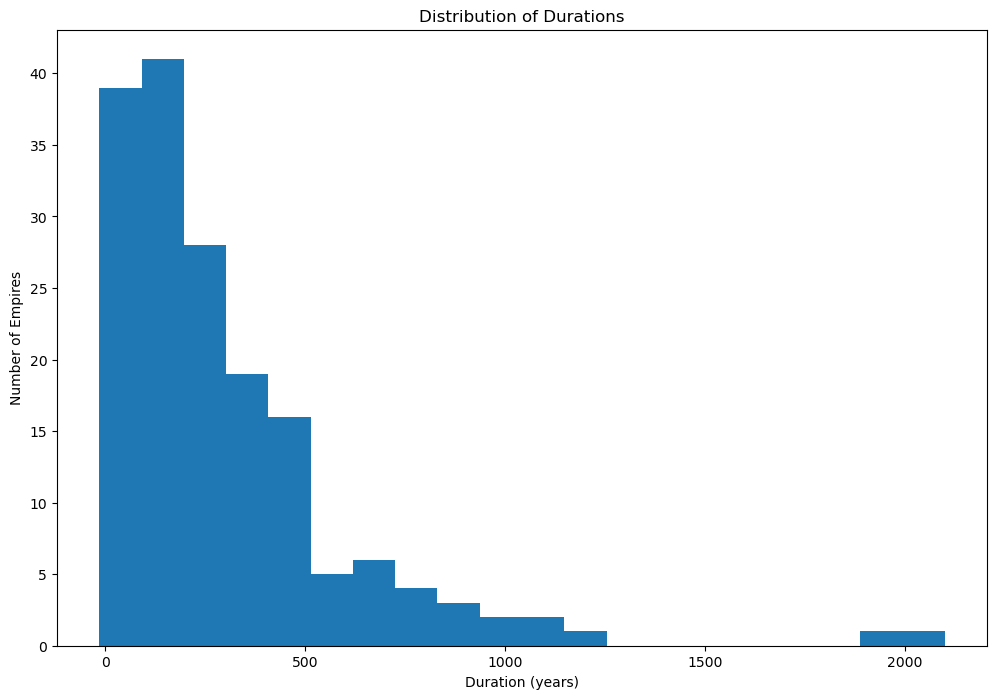

In [112]:
#display the distribution of duration
plt.figure(figsize=(12,8))
plt.hist(df_empire['duration'], bins=20)
plt.title("Distribution of Durations")
plt.xlabel("Duration (years)")
plt.ylabel("Number of Empires")
plt.show()

This histogram is rightly skewed, showing majority of empires are short-lived, between 0-500 years. There are outlier showing few empires that are close to 2000 years of duration.  

In [113]:
df_empire['country_name']

0      [Afghanistan, United Arab Emirates, Armenia, A...
1                                    [Brunei, Indonesia]
2      [Afghanistan, United Arab Emirates, Armenia, A...
3      [Afghanistan, United Arab Emirates, Armenia, A...
4                                    [Ethiopia, Somalia]
                             ...                        
163                                 [China, North Korea]
164    [Libya, Algeria, Spain, Gibraltar, Morocco, Po...
165                                    [China, Mongolia]
166    [Russia, China, North Korea, Myanmar, Mongolia...
167    [Armenia, Azerbaijan, Iran, Iraq, Kuwait, Russia]
Name: country_name, Length: 168, dtype: object